# SVM Email/SMS Spam Detection — Final Version

A complete, professional implementation of a **spam classifier using Support Vector Machines (SVM)**.

**Pipeline:** raw text → TF-IDF features → SVM (Linear vs. RBF kernel) → hyperparameter tuning (`C`) →
evaluation → final model → inference on new messages.

**Dataset:** SMS Spam Collection (`spam.csv`) — labeled `spam` / `ham` text messages.


## 1. Imports


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.feature_extraction.text import TfidfVectorizer


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.fa
cecolor'] = 'white'
%matplotlib inline


## 2. Load and Inspect the Data

We load the raw CSV, keep only the relevant columns, and encode the target label as a binary
integer (`1 = spam`, `0 = ham`). We also check the class balance — spam datasets are typically
**imbalanced**, so accuracy alone will not be a reliable metric later on.

In [2]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})
df['y'] = (df['label'] == 'spam').astype(int)
df = df.dropna(subset=['text']).reset_index(drop=True)

print(f'Total messages: {len(df)}')
print('\nClass distribution:')
print(df['label'].value_counts())
print(f"\nSpam ratio: {df['y'].mean() * 100:.1f}%")

df.head()


Total messages: 5572

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Spam ratio: 13.4%


,label,text,y
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


## 3. Train / Test Split

We hold out 20% of the data for testing. `stratify=y` keeps the spam/ham ratio consistent
between the training and test sets, which matters given the class imbalance above.

In [3]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['text'], df['y'],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df['y']
)

print(f'Training messages: {len(X_train_text)}')
print(f'Test messages:     {len(X_test_text)}')


Training messages: 4457
Test messages:     1115


## 4. Feature Extraction — TF-IDF

SVM requires numeric input, so we convert each message into a **TF-IDF** vector. Every unique
word becomes a feature; the value reflects how important that word is to a given message
relative to the whole corpus.

**Why this matters for kernel choice:** once vectorized, the number of features `n` (vocabulary
size) is usually much larger than the number of training examples `m`. In that `n > m` regime,
a **Linear Kernel SVM** is generally the safer, recommended choice — a Gaussian/RBF kernel is
more prone to overfitting when features vastly outnumber examples.

In [ ]:
tfidf = TfidfVectorizer(stop_words='english', max_features=3000, min_df=2)
X_train = tfidf.fit_transform(X_train_text)   # learn vocabulary + transform
X_test = tfidf.transform(X_test_text)         # reuse the same vocabulary (no data leakage)

n = X_train.shape[1]       # number of features (vocabulary size)
m_train = X_train.shape[0] # number of training examples

print(f'n (features)          = {n}')
print(f'm (training examples) = {m_train}')
print(f'n > m ? {n > m_train}  -> favors a LINEAR kernel')


n (features)          = 3000
m (training examples) = 4457
n > m ? False  -> favors a LINEAR kernel


## 5. Model 1 — Linear Kernel SVM

We train our baseline model using a linear decision boundary, consistent with the `n > m`
reasoning above.

In [5]:
svm_linear = SVC(kernel='linear', C=1.0)
svm_linear.fit(X_train, y_train)

train_acc = accuracy_score(y_train, svm_linear.predict(X_train)) * 100
test_acc = accuracy_score(y_test, svm_linear.predict(X_test)) * 100

print(f'Linear Kernel SVM -> Train accuracy: {train_acc:.2f}%   Test accuracy: {test_acc:.2f}%')


Linear Kernel SVM -> Train accuracy: 99.46%   Test accuracy: 98.21%


## 6. Evaluation — Confusion Matrix and Classification Report

Because the classes are imbalanced, accuracy alone is not enough. The confusion matrix and
`classification_report` (precision, recall, F1-score) give a fuller picture.

**Context:** a *False Positive* (ham classified as spam) buries a real message in the spam
folder — usually the costlier mistake for a spam filter. A *False Negative* (spam classified
as ham) lets a spam message through.

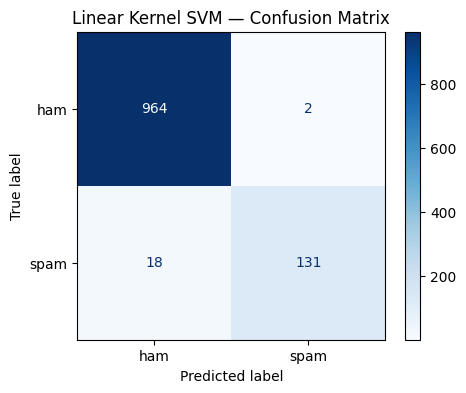

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.98      0.88      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [6]:
y_pred = svm_linear.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ham', 'spam'])
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Linear Kernel SVM — Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))


## 7. Model 2 — RBF (Gaussian) Kernel SVM

For comparison, we train an SVM with an RBF kernel, which can draw non-linear decision
boundaries. `gamma` here plays the same role as `sigma` in the Gaussian kernel formula:

$$gamma = \frac{1}{2\sigma^2}$$

We expect the linear kernel to perform at least as well, given `n > m`.

In [7]:
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_rbf.fit(X_train, y_train)

test_acc_rbf = accuracy_score(y_test, svm_rbf.predict(X_test)) * 100

print(f'RBF Kernel SVM    -> Test accuracy: {test_acc_rbf:.2f}%')
print(f'Linear Kernel SVM -> Test accuracy: {test_acc:.2f}%')


RBF Kernel SVM    -> Test accuracy: 97.76%
Linear Kernel SVM -> Test accuracy: 98.21%


## 8. Hyperparameter Tuning — Effect of `C`

`C` controls the regularization trade-off:
- **Small `C`** -> stronger regularization -> simpler boundary -> risk of **underfitting**
  (high bias).
- **Large `C`** -> weaker regularization -> the model fits training data more closely ->
  risk of **overfitting** (high variance).

We sweep several values of `C` and plot train vs. test accuracy to visualize this trade-off.

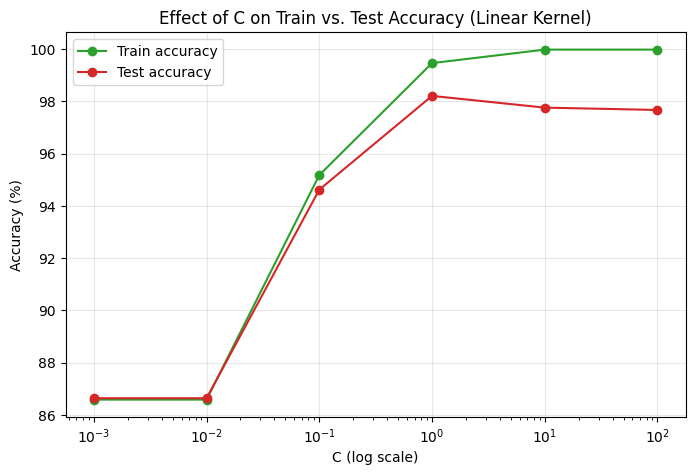

C=0.001    Train=86.58%  Test=86.64%
C=0.01     Train=86.58%  Test=86.64%
C=0.1      Train=95.18%  Test=94.62%
C=1        Train=99.46%  Test=98.21%
C=10       Train=99.98%  Test=97.76%
C=100      Train=99.98%  Test=97.67%


In [8]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
train_accs, test_accs = [], []

for C in C_values:
    model = SVC(kernel='linear', C=C)
    model.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, model.predict(X_train)) * 100)
    test_accs.append(accuracy_score(y_test, model.predict(X_test)) * 100)

plt.figure(figsize=(8, 5))
plt.plot(C_values, train_accs, 'o-', label='Train accuracy', color='#2ca02c')
plt.plot(C_values, test_accs, 'o-', label='Test accuracy', color='#d62728')
plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Accuracy (%)')
plt.title('Effect of C on Train vs. Test Accuracy (Linear Kernel)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for C, tr, te in zip(C_values, train_accs, test_accs):
    print(f'C={C:<8} Train={tr:5.2f}%  Test={te:5.2f}%')


## 9. Final Model

Based on the evaluation above, we select the **Linear Kernel SVM with `C = 1`** as the final
model: it matches the theoretical `n > m` guidance, generalizes well (small train/test gap),
and is simple and fast to train.

In [9]:
final_model = svm_linear  # kernel='linear', C=1.0, already trained above

final_test_acc = accuracy_score(y_test, final_model.predict(X_test)) * 100
print(f'Final model test accuracy: {final_test_acc:.2f}%')


Final model test accuracy: 98.21%


## 10. Inference — Predicting New Messages

A small helper function wraps the trained vectorizer and model together, so any new raw text
can be classified directly. `decision_function` returns the raw margin score (distance from
the decision boundary) — larger positive values mean higher confidence of spam.

In [10]:
def predict_message(text: str) -> tuple[str, float]:
    """
    Classify a raw text message as spam or ham.

    Parameters
    ----------
    text : str
        The raw message text.

    Returns
    -------
    label : str
        'SPAM' or 'ham'.
    score : float
        The SVM decision function value (margin distance).
    """
    vec = tfidf.transform([text])
    pred = final_model.predict(vec)[0]
    score = final_model.decision_function(vec)[0]
    label = 'SPAM' if pred == 1 else 'ham'
    return label, score


test_messages = [
    "Congratulations! You have WON a $1000 Walmart gift card. Click here to claim now!!!",
    "Hey, are we still meeting for coffee tomorrow at 10?",
    "URGENT: Your account has been suspended, verify your password immediately at this link",
    "Mom said dinner is ready, come down when you can",
]

for msg in test_messages:
    label, score = predict_message(msg)
    preview = msg if len(msg) <= 60 else msg[:60] + '...'
    print(f'[{label:5}] (score={score:+.2f})  "{preview}"')


[SPAM ] (score=+0.52)  "Congratulations! You have WON a $1000 Walmart gift card. Cli..."
[ham  ] (score=-1.29)  "Hey, are we still meeting for coffee tomorrow at 10?"
[SPAM ] (score=+0.80)  "URGENT: Your account has been suspended, verify your passwor..."
[ham  ] (score=-1.73)  "Mom said dinner is ready, come down when you can"


## 11. Summary

| Step | What was done |
|---|---|
| Data loading | Loaded `spam.csv`, encoded labels as 0/1, checked class balance |
| Split | 80/20 train/test split, stratified on the target |
| Features | TF-IDF vectorization (`max_features=3000`, English stop words removed) |
| Kernel choice | `n > m` (vocabulary >> training examples) -> Linear Kernel recommended |
| Model 1 | Linear Kernel SVM (`C=1`) — evaluated with confusion matrix & classification report |
| Model 2 | RBF Kernel SVM — compared against the linear model |
| Tuning | Swept `C` across 6 values; observed the bias/variance trade-off |
| Final model | Linear Kernel SVM (`C=1`), wrapped in a reusable `predict_message()` function |

This same pipeline (TF-IDF → Linear-Kernel SVM) generalizes directly to full **email** spam
detection — swap `spam.csv` for an email dataset (subject + body as the `text` column) and the
rest of the notebook still applies.